## WHAT IS RAG? 

RAG stands for Retrieval Augmented Generation. 

The goal of RAG is to take information and pass it to an LLM so it can generate ouputs based on that information. 

* Retrieval: Find / search for relevant information given a query. EX// "What are the macronutrients and what do they do?" -> retrieves passages of text related to the macronutrients from a nutrition textbook 

* Augmented: We want to take the relevant information and augment our input (prompt) to an LLM with that relevant information

* Generation: Take the first two steps and pass them to an LLM for generative outputs 

## WHY RAG 

The main goal of RAG is to improve the generation outputs of LLMs. 

1. Prevent Hallucinations: LLMs are incredibly good at generating text that appears good looking, however, it might not be factual. RAG can help LLM generate information based on relevant passages that are factual. 

2. Work With Custom Data: Many base LLMs are trained with internet-scale data. This means they have a fairly good understanding of language in general. RAG helps to create specific responses based on specific documents. EX// company customer support documents 

## RAG USE CASES 

* Customer Support Q&A Chat: Treat existing customer support documents as a resource. Retrieve relevant documentation snippets and have an LLM craft those snippets into an answer to a user's question. "Chatbot for your documentation" 

* Email Chain Analysis: A large insurance company uses a RAG pipeline to find relevant information from large amount of email chains about customer claims and process the information into structured data. 

* Company Internal Documentation Chat 

* Textbook Q&A: A nutrition student has a 1200 page textbook to read. Build a RAG pipeline to go through the textbook and find relevant passages to the questions you have. 

The common theme among these is taking your relevant documents to a query and process them with an LLM. The LLM acts as a calculator for words. 

## BENEFITS OF RUNNING LOCALLY 

* Privacy: If you have private information, maybe you don't want to send that to an API. You want to setup an LLM and run it on your own hardware.

* Speed: Whenever you use an API you have to send data across the internet which takes time. Running locally means we don't have to wait to transfer the data. 

* Cost: If you own the hardware, the cost is fixed / paid for. It may have a large upfront cost but overtime you don't have to keep paying fees. 

* No Vendor Lockin: If you run your own software/hardware, not dependant on businesses maintaining software. 

## WHAT WE'RE GOING TO BUILD 

We're going to build NutriChat to chat with the nutrition textbook.

Specifically: 

1. Open a PDF document (any PDF or collection of PDFs)

2. Format the text of the PDF textbook ready for an embedding model 

3. Embed all of the chunks of text in the textbook and turn them into numerical representations (embeddings) which we can store for later 

4. Build a retrieval system that uses vector search to find relevant chunks of text based on a query. 

5. Create a prompt that incorporates the retrieved pieces of text. 

6. Generate an answer to a query based on the passages of the textbook with an LLM

(All Done Locally) 

1. Steps 1-3: Document Preprocessing and Embedding Creation 

2. Steps 4-6: Search and Answer 


## 1. DOCUMENT / TEXT PREPROCESSING 

Need: 

* PDF document of choice 
* Embedding model of choice 

Steps: 

1. Import PDF document 
2. Process text forr embedding (split into chunks of sentences) 
3. Embed text chunks with embedding model 
4. Save embeddings to file for later 

### Import PDF Document

In [3]:
import os 
import requests

# get pdf document path 
pdf_path = 'human-nutrition-text.pdf'

# download 
if not os.path.exists(pdf_path):
    print(f"[INFO] File doesn't exist, downloading...")
    # enter the url of the pdf 
    url = "https://pressbooks.oer.hawaii.edu/humannutrition2/open/download?type=pdf"
    filename = pdf_path
    # send get request
    response = requests.get(url)
    # check if request is successful 
    if response.status_code == 200:
        # open file and save it 
        with open(filename, 'wb') as file:
            file.write(response.content)
        print(f"[INFO] The file has been downloaded and saved as {filename}")
    else:
        print(f"[INFO] Failed to download the file. Status Code: {response.status_code}")
else: 
    print(f"File {pdf_path} exists")

File human-nutrition-text.pdf exists


Opening the PDF 

In [4]:
import fitz # reading pdfs 
from tqdm.auto import tqdm 

def text_formatter(text: str) -> str: 
    """Performs minor formatting on text"""
    cleaned_text = text.replace('\n', ' ').strip()
    # insert more text formatting functions 
    # better the format, the better the responses 
    return cleaned_text

def open_and_read_pdf(pdf_path: str) -> list[dict]:
    doc = fitz.open(pdf_path)
    pages_and_texts = []
    # iterate through document 
    # append pages of text to list 
    for page_number, page in tqdm(enumerate(doc)):
        text = page.get_text()
        text = text_formatter(text=text)
        pages_and_texts.append({"page_number" : page_number - 41,
                                "page_char_count" : len(text),
                                "page_word_count" : len(text.split(" ")),
                                "page_sentence_count_raw": len(text.split(". ")),
                                "page_token_count": len(text) / 4, # 1 token ~4 charachters
                                "text" : text
                                })
    return pages_and_texts

pages_and_texts = open_and_read_pdf(pdf_path=pdf_path)
pages_and_texts[:3]

0it [00:00, ?it/s]

[{'page_number': -41,
  'page_char_count': 29,
  'page_word_count': 4,
  'page_sentence_count_raw': 1,
  'page_token_count': 7.25,
  'text': 'Human Nutrition: 2020 Edition'},
 {'page_number': -40,
  'page_char_count': 0,
  'page_word_count': 1,
  'page_sentence_count_raw': 1,
  'page_token_count': 0.0,
  'text': ''},
 {'page_number': -39,
  'page_char_count': 320,
  'page_word_count': 54,
  'page_sentence_count_raw': 1,
  'page_token_count': 80.0,
  'text': 'Human Nutrition: 2020  Edition  UNIVERSITY OF HAWAI‘I AT MĀNOA  FOOD SCIENCE AND HUMAN  NUTRITION PROGRAM  ALAN TITCHENAL, SKYLAR HARA,  NOEMI ARCEO CAACBAY, WILLIAM  MEINKE-LAU, YA-YUN YANG, MARIE  KAINOA FIALKOWSKI REVILLA,  JENNIFER DRAPER, GEMADY  LANGFELDER, CHERYL GIBBY, CHYNA  NICOLE CHUN, AND ALLISON  CALABRESE'}]

In [5]:
import random 

random.sample(pages_and_texts, k=3)

[{'page_number': 1041,
  'page_char_count': 84,
  'page_word_count': 17,
  'page_sentence_count_raw': 3,
  'page_token_count': 21.0,
  'text': 'PART XVIII  CHAPTER 18.  NUTRITIONAL ISSUES  Chapter 18. Nutritional Issues  |  1041'},
 {'page_number': 472,
  'page_char_count': 641,
  'page_word_count': 105,
  'page_sentence_count_raw': 5,
  'page_token_count': 160.25,
  'text': 'Photo by  Hope House  Press on  unsplash.co m / CC0  https://unspl ash.com/ photos/ PJzc7LOt2Ig  Weight Management  UNIVERSITY OF HAWAI‘I AT MĀNOA FOOD SCIENCE AND HUMAN  NUTRITION PROGRAM AND HUMAN NUTRITION PROGRAM  “Obesogenic” is a word that has sprung up in the language of public  health professionals in the last two decades. The Centers for  Disease Control and Prevention (CDC) defines obesogenic as “an  environment that promotes increased food intake, non-healthful  foods, and physical inactivity.”1  1. Obesogenic Environments. Center for Disease Control  and Prevention (CDC). https://www.cdc.gov/pcd/ 472  

In [6]:
import pandas as pd 

df = pd.DataFrame(pages_and_texts)
df.head()

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,text
0,-41,29,4,1,7.25,Human Nutrition: 2020 Edition
1,-40,0,1,1,0.00,
2,-39,320,54,1,80.00,Human Nutrition: 2020 Edition UNIVERSITY OF ...
3,-38,212,32,1,53.00,Human Nutrition: 2020 Edition by University of...
4,-37,797,147,3,199.25,Contents Preface University of Hawai‘i at Mā...


In [7]:
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count
count,1208.00,1208.00,1208.00,1208.00,1208.00
mean,562.50,1148.00,199.50,10.52,287.00
std,348.86,560.38,95.83,6.55,140.10
min,-41.00,0.00,1.00,1.00,0.00
25%,260.75,762.00,134.00,5.00,190.50
50%,562.50,1231.50,216.00,10.00,307.88
75%,864.25,1603.50,272.00,15.00,400.88
max,1166.00,2308.00,430.00,39.00,577.00


Why do we care about token count? 

Token count is important to think about because: 

1. Embedding models don't deal with infinite tokens 
2. LLMs don't deal with infinite tokens 

For example, an embedding model may have been trained to embed sequences of 384 tokens into numerical space. (sentence-transformeers `all-mpnet-base-v2`)

Look at mteb embedding leaderboard on hugging face to compare max tokens and size of embedding models. Use rough token count to decide 

As for LLMs, they can't accept infinite tokens in their context window. (The number of tokens an LLM can accept as input) 

### Further Text Processing (splitting pages into sentences) 

Two ways to do this: 

1. we've done this by splitting on '. ' 
2. we can do this with natural language processing library such as `spaCy` and `nltk `

In [8]:
from spacy.lang.en import English 

nlp = English()

# add sentencizer pipeline - turning text into sentences
# see https://spacy.io/api/sentencizer
nlp.add_pipe("sentencizer")

# crete document instance as an example 
doc = nlp("This is a sentence. This is another sentence. I like elephants.")
assert len(list(doc.sents)) == 3

# print out our sentences split 
list(doc.sents)

[This is a sentence., This is another sentence., I like elephants.]

In [9]:
pages_and_texts[600]

{'page_number': 559,
 'page_char_count': 863,
 'page_word_count': 138,
 'page_sentence_count_raw': 9,
 'page_token_count': 215.75,
 'text': 'Image by  Allison  Calabrese /  CC BY 4.0  Korsakoff syndrome can cause similar symptoms as beriberi such  as confusion, loss of coordination, vision changes, hallucinations,  and may progress to coma and death. This condition is specific  to alcoholics as diets high in alcohol can cause thiamin deficiency.  Other individuals at risk include individuals who also consume diets  typically low in micronutrients such as those with eating disorders,  elderly, and individuals who have gone through gastric bypass  surgery.5  Figure 9.10 The Role of Thiamin  Figure 9.11 Beriberi, Thiamin Deficiency  5. Fact Sheets for Health Professionals: Thiamin. National  Institute of Health, Office of Dietary Supplements.   https://ods.od.nih.gov/factsheets/Thiamin- HealthProfessional/. Updated Feburary 11, 2016.  Accessed October 22, 2017.  Water-Soluble Vitamins  | 

In [10]:
for item in tqdm(pages_and_texts):
    item['sentences'] = list(nlp(item['text']).sents)

    # make sure all sentences are strings 
    # default type is a spacy datatype 
    item['sentences'] = [str(sentence) for sentence in item['sentences']]

    # count the sentences 
    item['page_sentence_count_spacy'] = len(item['sentences'])

  0%|          | 0/1208 [00:00<?, ?it/s]

In [11]:
random.sample(pages_and_texts, k=1)

[{'page_number': 805,
  'page_char_count': 893,
  'page_word_count': 139,
  'page_sentence_count_raw': 8,
  'page_token_count': 223.25,
  'text': 'Learning Activities  Technology Note: The second edition of the Human  Nutrition Open Educational Resource (OER) textbook  features interactive learning activities.  These activities are  available in the web-based textbook and not available in the  downloadable versions (EPUB, Digital PDF, Print_PDF, or  Open Document).  Learning activities may be used across various mobile  devices, however, for the best user experience it is strongly  recommended that users complete these activities using a  desktop or laptop computer and in Google Chrome.    An interactive or media element has been  excluded from this version of the text. You can  view it online here:  http://pressbooks.oer.hawaii.edu/ humannutrition2/?p=446  gestational diabetes: The influence of changing  diagnostic criteria. World Journal of Diabetes, 6(2),  234–244. https://doi.org/1

In [12]:
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_spacy
count,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00
mean,562.50,1148.00,199.50,10.52,287.00,10.32
std,348.86,560.38,95.83,6.55,140.10,6.30
min,-41.00,0.00,1.00,1.00,0.00,0.00
25%,260.75,762.00,134.00,5.00,190.50,5.00
50%,562.50,1231.50,216.00,10.00,307.88,10.00
75%,864.25,1603.50,272.00,15.00,400.88,15.00
max,1166.00,2308.00,430.00,39.00,577.00,28.00


### Chunking Text (Getting text into smaller groups)

The concept of splitting larger pieces of text into smaller ones is often reffered to as text splitting or chunking. 

There is no 100% correct way to do this. 

To keep it simple, we will split into groups of 10 sentences.  

There are frameworks such as `LangChain` that can help with this 

Why we do this: 

1. So texts are easier to filter (smaller groups of text can be easier to inspect than large passages)
2. So text chunks can fit into embedding model context window
3. So contexts passed to an LLM can be more specific and focused 

In [13]:
# define split size to turn gorups of sentences into chunks 
num_sentence_chunk_size = 10 

# func to split lists of texts recursively into chunk size 
# ex// list of 20 -> [10, 10] or [25] -. [10, 10, 5]
def split_list(input_list: list[str],
               slice_size: int=num_sentence_chunk_size) -> list[list[str]]:
    
    return [input_list[i : i + slice_size] for i in range(0,
                                                          len(input_list),
                                                          slice_size)]

test_list = list(range(25))
split_list(test_list)

[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [20, 21, 22, 23, 24]]

In [14]:
# loop through pages and texts and split sentences in chunks 
for item in tqdm(pages_and_texts):
    item['sentence_chunks'] = split_list(input_list=item['sentences'],
                                         slice_size=num_sentence_chunk_size)
    # count num of chunks 
    item['num_chunks'] = len(item['sentence_chunks'])

  0%|          | 0/1208 [00:00<?, ?it/s]

In [15]:
random.sample(pages_and_texts, k=1)

[{'page_number': 439,
  'page_char_count': 1045,
  'page_word_count': 181,
  'page_sentence_count_raw': 9,
  'page_token_count': 261.25,
  'text': 'Microsomal Ethanol Oxidizing System  (MEOS)  In a moderate drinker, about 10 to 20% of the total liver ethanol  uptake is processed via the microsomal ethanol oxidizing system  (MEOS). During periods of heavy drinking, the MEOS system will  metabolize most of the excess ethanol ingested. Heavy drinking  stimulates the human body to include the MEOS system enzymes to  clear ethanol faster from the body.  The MEOS system is also located in the liver. Similar to the  Alcohol dehydrogenase system, acetaldehyde dehydrogenase will  immediately convert acetaldehyde into acetate, a non-toxic  molecule. Other products from this reaction are NADH and H+ ion.  Fate of Acetate  The acetate produced (from the alcohol dehydrogenase system and  microsomal ethanol oxidizing system) is either released into  circulation or retained inside the liver cells. In

In [16]:
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_spacy,num_chunks
count,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00
mean,562.50,1148.00,199.50,10.52,287.00,10.32,1.53
std,348.86,560.38,95.83,6.55,140.10,6.30,0.64
min,-41.00,0.00,1.00,1.00,0.00,0.00,0.00
25%,260.75,762.00,134.00,5.00,190.50,5.00,1.00
50%,562.50,1231.50,216.00,10.00,307.88,10.00,1.00
75%,864.25,1603.50,272.00,15.00,400.88,15.00,2.00
max,1166.00,2308.00,430.00,39.00,577.00,28.00,3.00


No we want each chunk to be it's own item in the dictionary. 

### Splitting Each Chunk Into Its Own Item 

We'd like to embed each chunk of sentences into its own numerical representation. 

That will give us a good level of granularity 

Meaning we can dive specifically into the text sample that was used in our model 

In [17]:
import re 

# split each chunk into its own item 

pages_and_chunks = []
for item in tqdm(pages_and_texts):
    # break chunks 
    for sentence_chunk in item['sentence_chunks']:
        chunk_dict = {}
        chunk_dict['page_number'] = item['page_number']
        
        # join sentences back into paragraph like structure 
        # join list of sentences into one paragraph  
        joined_sentence_chunk = "".join(sentence_chunk).replace("  ", " ").strip()
        # after a period followed by any capital letter replace it with a space
        joined_sentence_chunk = re.sub(r'\.([A-Z])', r'. \1', joined_sentence_chunk)
        chunk_dict['sentence_chunk'] = joined_sentence_chunk
        # statistics on chunks 
        chunk_dict['chunk_char_count'] = len(joined_sentence_chunk)
        chunk_dict['chunk_word_count'] = len([word for word in joined_sentence_chunk.split(" ")])
        chunk_dict['chunk_token_count'] = len(joined_sentence_chunk) / 4

        pages_and_chunks.append(chunk_dict)


len(pages_and_chunks)

  0%|          | 0/1208 [00:00<?, ?it/s]

1843

In [18]:
random.sample(pages_and_chunks, k=1)

[{'page_number': 431,
  'sentence_chunk': 'Image by Allison Calabrese / CC BY 4.0 Introduction UNIVERSITY OF HAWAI‘I AT MĀNOA FOOD SCIENCE AND HUMAN NUTRITION PROGRAM AND HUMAN NUTRITION PROGRAM Ka wai hoʻomalule kino The liquid that causes limpness to the body Learning Objectives By the end of this chapter, you will be able to: Introduction | 431',
  'chunk_char_count': 306,
  'chunk_word_count': 52,
  'chunk_token_count': 76.5}]

In [19]:
df = pd.DataFrame(pages_and_chunks)
df.describe().round(2)

,page_number,chunk_char_count,chunk_word_count,chunk_token_count
count,1843.00,1843.00,1843.00,1843.00
mean,583.38,734.10,112.74,183.52
std,347.79,447.51,71.24,111.88
min,-41.00,12.00,3.00,3.00
25%,280.50,315.00,45.00,78.75
50%,586.00,745.00,115.00,186.25
75%,890.00,1118.00,173.00,279.50
max,1166.00,1830.00,297.00,457.50


Some chunks will lose information in the embedding model, the majority will not lose information but some will. 

### Filter Chunks of text for short chunks 

These chunks may not contain much useful information 

In [20]:
# show random chunks with under 30 tokens in length 
min_token_length = 30 
for row in df[df['chunk_token_count'] <= min_token_length].sample(5).iterrows():
    print(f'Chunk token count: {row[1]['chunk_token_count']} | text: {row[1]['sentence_chunk']}')


Chunk token count: 9.75 | text: 920 | Older Adulthood: The Golden Years
Chunk token count: 16.25 | text: Updated January 2015. Accessed December 4, 2017. Middle Age | 917
Chunk token count: 9.75 | text: 1002 | The Causes of Food Contamination
Chunk token count: 10.5 | text: 442 | Health Consequences of Alcohol Abuse
Chunk token count: 13.0 | text: Accessed October 5, 2017. 540 | Fat-Soluble Vitamins


In [21]:
# filter data frame for rows with under 30 tokens 
pages_and_chunks_over_min_token_len = df[df['chunk_token_count'] > min_token_length].to_dict(orient='records')
pages_and_chunks_over_min_token_len[:2]

[{'page_number': -39,
  'sentence_chunk': 'Human Nutrition: 2020 Edition UNIVERSITY OF HAWAI‘I AT MĀNOA FOOD SCIENCE AND HUMAN NUTRITION PROGRAM ALAN TITCHENAL, SKYLAR HARA, NOEMI ARCEO CAACBAY, WILLIAM MEINKE-LAU, YA-YUN YANG, MARIE KAINOA FIALKOWSKI REVILLA, JENNIFER DRAPER, GEMADY LANGFELDER, CHERYL GIBBY, CHYNA NICOLE CHUN, AND ALLISON CALABRESE',
  'chunk_char_count': 308,
  'chunk_word_count': 42,
  'chunk_token_count': 77.0},
 {'page_number': -38,
  'sentence_chunk': 'Human Nutrition: 2020 Edition by University of Hawai‘i at Mānoa Food Science and Human Nutrition Program is licensed under a Creative Commons Attribution 4.0 International License, except where otherwise noted.',
  'chunk_char_count': 210,
  'chunk_word_count': 30,
  'chunk_token_count': 52.5}]

In [22]:
random.sample(pages_and_chunks_over_min_token_len, k=1)

[{'page_number': 112,
  'sentence_chunk': '“Urine Color” by OpenStax College / CC BY 3.0 Urine volume varies considerably. The normal range is one to two liters per day. The kidneys must produce a minimum urine volume of about 500 mL/day to rid the body of wastes. Output below this level may be caused by severe dehydration or renal disease and is termed oliguria. The virtual absence of urine production is 112 | The Urinary System',
  'chunk_char_count': 390,
  'chunk_word_count': 70,
  'chunk_token_count': 97.5}]

## 1.5 EMBEDDING TEXT CHUNKS

Embeddings are a broad but powerful concept 

While humans understand text, machines understand numbers 

What we'd like to do: 
- Turn text chunks into numbers, specifically embeddings 

Embedding: a useful numerical representation. *A learned representation*

Paper on embeddings: https://vickiboykis.com/what_are_embeddings/

### Embedding Model 

- there are many different embedding models you can use depending on size and needs (see hugging face leaderboard) 

see https://sbert.net

In [ ]:
from sentence_transformers import SentenceTransformer

# good baseline all around model 
embedding_model = SentenceTransformer(model_name_or_path="all-mpnet-base-v2",
                                      device="cpu")

# create a list of sentences to embed 
# embeddings caputre the meaning of sentence numeric
sentences = ['The sentence transformer library provides an easy way to create embeddings.',
             'Sentences can be embedded one by one, or in a list.',
             'I like horses!']

# sentences are encoded / embedded by calling model.encode()
embeddings = embedding_model.encode(sentences)
embeddings_dict = dict(zip(sentences, embeddings))

# see the embeddings 
for sentence, embedding in embeddings_dict.items():
    print(f"sentence: {sentence}")
    print(f"embedding: {embedding}")
    print("")

In [ ]:
embedding = embedding_model.encode('My favorite animal is the cow')
embedding

In [ ]:
%%time 

embedding_model.to("cpu")
# embed each chunk one by one 
for item in tqdm(pages_and_chunks_over_min_token_len):
    item["embedding"] = embedding_model.encode(item["sentence_chunk"])


Batch embedding with gpus 

In [ ]:
# embedding_model.to("cuda")
# # embed each chunk one by one 
# for item in tqdm(pages_and_chunks_over_min_token_len):
#     item["embedding"] = embedding_model.encode(item["sentence_chunk"])

## gpu in batch mode 
# text_chunks = [item['sentence_chunk'] for item in pages_and_chunks_over_min_token_len]
# text_chunks[419]

# # embedd all texts in batches
# text_chunk_embeddings = embedding_model.encode(text_chunks,
#                                                batch_size=32,# experiment to find what batch size leads to best results (SPEED) 
#                                                convert_to_tensor=True) 

### Save embeddings to file so they can be used later 

In [ ]:
# save embeddings 
text_chunks_and_embeddings_df = pd.DataFrame(pages_and_chunks_over_min_token_len)
embeddings_df_save_path = 'text_chunks_and_embeddings_df.csv'
text_chunks_and_embeddings_df.to_csv(embeddings_df_save_path, index=False)

If your embedding database is really large (over 100k-1M samples) you may want to look into using a vector database for storage 

(see question and answer section about embeddings) 


## 2. RAG - Search and Answer

RAG goal: retrieve relevant passages based on a query and use those passages to augment an input to an LLM so it can generate an output based on those relevant passages. 

### Similarity Search 

Embeddings can be used for almost any type of data 

EX// images, sound, text can be turned into embeddings 

Comparing embeddings is known as similarity search or vector search or semantic search 

In our case, we want to query our nutrition textbook passages based on semantics or "vibe" 

If I search 'macronutrients functions' I should get relevant passages to that text. but may not contain those specific words 

Whereas with keyword search, if I search "apple" i get passages back with spefically 'apple' 

In [23]:
import torch 
import numpy as np 
import random
import pandas as pd

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# import text and embeddings df 
text_chunks_and_embeddings_df = pd.read_csv('./text_chunks_and_embeddings_df.csv')

# convert embedding column back to np.array - it got converted to a string when saved to csv
text_chunks_and_embeddings_df['embedding'] = text_chunks_and_embeddings_df['embedding'].apply(lambda x: np.fromstring(x.strip("[]"),
                                                                                                                      sep = " "))

# convert embeddings into a torch.tensor 
embeddings = torch.tensor(np.stack(text_chunks_and_embeddings_df['embedding'].to_list(), axis=0),
                                   dtype=torch.float32)

# convert texts and embedding df to list of dicts 
pages_and_chunks = text_chunks_and_embeddings_df.to_dict(orient='records')

text_chunks_and_embeddings_df



,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
0,-39,Human Nutrition: 2020 Edition UNIVERSITY OF HA...,308,42,77.00,"[0.0674242601, 0.0902280584, -0.00509548606, -..."
1,-38,Human Nutrition: 2020 Edition by University of...,210,30,52.50,"[0.0552156493, 0.059213791, -0.0166167803, -0...."
2,-37,Contents Preface University of Hawai‘i at Māno...,766,116,191.50,"[0.0279801451, 0.0339813605, -0.0206427146, 0...."
3,-36,Lifestyles and Nutrition University of Hawai‘i...,941,144,235.25,"[0.0682567134, 0.0381274335, -0.00846858136, -..."
4,-35,The Cardiovascular System University of Hawai‘...,998,152,249.50,"[0.033026401, -0.00849776901, 0.00957155507, -..."
...,...,...,...,...,...,...
1675,1164,Flashcard Images Note: Most images in the flas...,1304,186,326.00,"[0.0185622927, -0.0164279956, -0.0127046118, -..."
1676,1164,Hazard Analysis Critical Control Points reused...,374,51,93.50,"[0.0334721878, -0.0570441112, 0.0151489526, -0..."
1677,1165,ShareAlike 11. Organs reused “Pancreas Organ A...,1285,175,321.25,"[0.077051416, 0.00978541095, -0.0121817086, 0...."
1678,1165,Sucrose reused “Figure 03 02 05” by OpenStax B...,410,63,102.50,"[0.103045113, -0.016470274, 0.00826844573, 0.0..."


In [24]:
embeddings.shape

torch.Size([1680, 768])

In [25]:
# Create sentence transformer model 
from sentence_transformers import util, SentenceTransformer

embedding_model = SentenceTransformer(model_name_or_path="all-mpnet-base-v2",
                                      device=device)

/Users/vivianjohnson/rag-env/lib/python3.12/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/Users/vivianjohnson/rag-env/lib/python3.12/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Embedding model ready 

Need to create a small semantic search pipeline 

In essence, we want to search for a query (ex - macronutrient functions) and get back relevant passages from the textbook 

We can do so with the following steps 

1. define a query string 
2. turn the query string into an embedding 
3. perform a dot product or cosine similarity function between the text embeddings and the query embedding 
4. sort the results from 3 in descending order 

Note: to use dot product for comparison, ensure vector sizes are of thd same shape and tensors/vectors are in the same data type 

Notes on Torch/Tensor/PyTorch

- tensor: specialized data structure, typically a multidimensional array used to store and maniupulate data in machine / deep learning frameworks 
    - multidimensional array for storring embeddings 

In [26]:
# 1. define the query 
query = "good foods for protein"
print(f'Query: {query}')

# 2. embed the query 
# note - important to embed query with same model you embedded the passages 
query_embedding = embedding_model.encode(query, convert_to_tensor=True)

# 3. get similiarity scores with the dot product (use cosine similarity if outputs of model aren't normalized) 
from time import perf_counter as timer 
start_time = timer()
# compare query embeddings to numbers in embeddings 
# dot product between two tensors 
dot_scores = util.dot_score(a=query_embedding,
                            b=embeddings)
end_time = timer() 

print(f"[INFO] Time taken to get scores on {len(embeddings)} embeddings: {end_time - start_time: .5f} seconds")

# 4. get the top k results - top 5 
top_results_dot_product = torch.topk(dot_scores, k=5)
top_results_dot_product

Query: good foods for protein
[INFO] Time taken to get scores on 1680 embeddings:  0.00090 seconds


torch.return_types.topk(
values=tensor([[0.7729, 0.7647, 0.6743, 0.6743, 0.6634]]),
indices=tensor([[611, 616, 615, 620, 617]]))

In [27]:
# take the index and index to get sentence 
pages_and_chunks[42]

{'page_number': 5,
 'sentence_chunk': 'Macronutrients Nutrients that are needed in large amounts are called macronutrients. There are three classes of macronutrients: carbohydrates, lipids, and proteins. These can be metabolically processed into cellular energy. The energy from macronutrients comes from their chemical bonds. This chemical energy is converted into cellular energy that is then utilized to perform work, allowing our bodies to conduct their basic functions. A unit of measurement of food energy is the calorie. On nutrition food labels the amount given for “calories” is actually equivalent to each calorie multiplied by one thousand. A kilocalorie (one thousand calories, denoted with a small “c”) is synonymous with the “Calorie” (with a capital “C”) on nutrition food labels. Water is also a macronutrient in the sense that you require a large amount of it, but unlike the other macronutrients, it does not yield calories. Carbohydrates Carbohydrates are molecules composed of car

In [28]:
# simulating with larger embeddings 
larger_embeddings = torch.randn(100*embeddings.shape[0], 768).to(device)
print(f"Embeddings shape: {larger_embeddings.shape}")

# perform dot product across 168000 embeddings 
start_time = timer()
# compare query embeddings to numbers in embeddings 
# dot product between two tensors 
dot_scores = util.dot_score(a=query_embedding,
                            b=larger_embeddings)
end_time = timer() 

print(f"[INFO] Time taken to get scores on {len(larger_embeddings)} embeddings: {end_time - start_time: .5f} seconds")

Embeddings shape: torch.Size([168000, 768])
[INFO] Time taken to get scores on 168000 embeddings:  0.01516 seconds


We can see that searching over embeddings is very fast even if we use exhaustive search (compare query embedding to every embedding). Which is precise but computationally wasteful. 

But if you had 10M+ embeddings, you likely want to create an index. 

An index is like letters in the dictionary. 

For example, if you wanted to search "duck" in the dictionary, you would start at "D" and then find words close to "Du" ... etc. 

An index helps to narror it down. A popular indexing library for vector search is `Faiss`. (facebook ai similarity search) One technique that the library provides is **approximate nearest neighbor search (ANN)**

Making Vector Search Results Pretty

In [29]:
import textwrap

def print_wrapped(text, wrap_length=80):
    wrapped_text = textwrap.fill(text, wrap_length)
    print(wrapped_text)

print(f"Query: '{query}' \n")
print(f"Results:")

# loop through zipped together scores and indicies from torch.topk 
scores, indices = top_results_dot_product
for score, idx in zip(scores[0], indices[0]):
    print(f"Score: {score:.4f}")
    print(f"Text:")
    print_wrapped(pages_and_chunks[idx]['sentence_chunk'])
    print(f"Page Number: {pages_and_chunks[idx]['page_number']}")
    print(f'\n')

Query: 'good foods for protein' 

Results:
Score: 0.7729
Text:
Dietary Sources of Protein The protein food group consists of foods made from
meat, seafood, poultry, eggs, soy, dry beans, peas, and seeds. According to the
Harvard School of Public Health, “animal protein and vegetable protein probably
have the same effects on health. It’s the protein package that’s likely to make
a difference.”1 1. Protein: The Bottom Line. Harvard School of Public Proteins,
Diet, and Personal Choices | 411
Page Number: 411


Score: 0.7647
Text:
Additionally, a person should consume 8 ounces of cooked seafood every week
(typically as two 4-ounce servings) to assure they are getting the healthy
omega-3 fatty acids that have been linked to a lower risk for heart disease.
Another tip is choosing to eat dry beans, peas, or soy products as a main dish.
Some of the menu choices include chili with kidney and pinto beans, hummus on
pita bread, and black bean enchiladas. You could also enjoy nuts in a variety of


Note: potential Extension 

We could potentially improve the order of these results with a reranking model. A model that has been trained specifically to take the search results (ex the top 25 emantic results) and rank them in order from most to least likely to relate to the query. 

Have open source models on hugging face

https://huggingface.com/mixedbread-ai/mxbai-rerank-large-v1

To check our results, what if we wanted to automatically surface the page of texts related to our query?

Text(0.5, 1.0, "Query: 'good foods for protein' | Most Relevant Page")

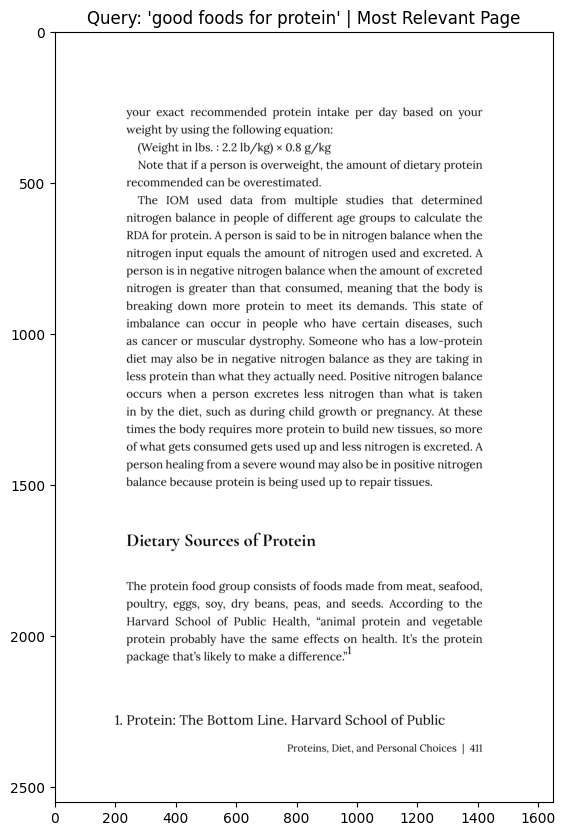

In [30]:
import fitz # pymupdf library

# open PDF and load target 
pdf_path = 'human-nutrition-text.pdf'
doc = fitz.open(pdf_path)
page = doc.load_page(411 + 41) # page numbers of pdf start 41+ 

# get image of the page 
img = page.get_pixmap(dpi=300)
# save image 
# img.save('output_filename.png')

# convert pixmap to numpy array 
img_array = np.frombuffer(img.samples_mv,
                          dtype=np.uint8).reshape((img.h,
                                                   img.w,
                                                   img.n))
# display using matplot lib
import matplotlib.pyplot as plt 
plt.figure(figsize=(13,10))
plt.imshow(img_array)
plt.title(f"Query: '{query}' | Most Relevant Page")

### Similarity Measures: Dot product and cosine similarity 

Two of the most common similarity measures between two vectors are dot product and cosine similarity. 

In essence, closer vectors will have higher scores, further away vectors will have lower scores. 

Vectors have direction and magnitude. Which way it is going and how long it is. 

Cosine similaritty is favored when doing semantic search on text. Magnitude is normalized it focuses only on direction

In [31]:
import torch 

def dot_product(vector1, vector2):
    return torch.dot(vector1, vector2)

def cosine_similarity(vector1, vector2):
    dot_product = torch.dot(vector1, vector2)
    # get euclidean/l2 norm
    norm_v1 = torch.sqrt(torch.sum(vector1**2))
    norm_v2 = torch.sqrt(torch.sum(vector2**2))

    return dot_product / (norm_v1 * norm_v2)

# example vector / tensors 
v1 = torch.tensor([1,2,3], dtype=torch.float32)
v2 = torch.tensor([1,2,3], dtype=torch.float32)
v3 = torch.tensor([4,5,6], dtype=torch.float32)
v4 = torch.tensor([-1,-2,-3], dtype=torch.float32)

# calculate dot product 
print(f"dot product between v1 and v2: {dot_product(v1, v2)}")
print(f"dot product between v1 and v3: {dot_product(v1, v3)}")
print(f"dot product between v1 and v4: {dot_product(v1, v4)}")

# cosine similarity
print(f"cosine similarity between v1 and v2: {cosine_similarity(v1, v2)}")
print(f"cosine similarity between v1 and v3: {cosine_similarity(v1, v3)}")
print(f"cosine similarity between v1 and v4: {cosine_similarity(v1, v4)}")

dot product between v1 and v2: 14.0
dot product between v1 and v3: 32.0
dot product between v1 and v4: -14.0
cosine similarity between v1 and v2: 0.9999999403953552
cosine similarity between v1 and v3: 0.9746317863464355
cosine similarity between v1 and v4: -0.9999999403953552


### Functionizing Sematic Search Pipeline

let's put all of the steps from above for sematic search into a function or two so we can repeat the workflow.

In [32]:
def retrieve_relevant_resources(query: str,
                                embeddings: torch.tensor,
                                model: SentenceTransformer=embedding_model,
                                n_resources_to_return: int=5,
                                print_time: bool=True):
    """
    Embeds a query with model and returns top k scores and indicies 
    from embeddings 
    """
    # embed query 
    query_embedding = model.encode(query, convert_to_tensor=True)

    # get dot product scores on embeddings 
    start_time = timer()
    dot_scores = util.dot_score(query_embedding,
                                embeddings)[0]
    end_time = timer()

    if print_time:
        print(f"[INFO] Time taken to get scores on ({len(embeddings)}) embeddings: {end_time - start_time:.5f} seconds")
    
    scores, indicies = torch.topk(input=dot_scores,
                                  k=n_resources_to_return)
    return scores, indicies

def print_top_results_and_scores(query: str,
                                 embeddings: torch.tensor,
                                 pages_and_chunks: list[dict]=pages_and_chunks,
                                 n_resources_to_return: int=5):
    """
    Finds relevant passages given a query and prints them out along with their scores 
    """

    scores, indicies = retrieve_relevant_resources(query=query,
                                                   embeddings=embeddings,
                                                   n_resources_to_return=n_resources_to_return)
    for score, idx in zip(scores, indicies):
        print(f"Score: {score:.4f}")
        print(f"Text:")
        print_wrapped(pages_and_chunks[idx]['sentence_chunk'])
        print(f"Page Number: {pages_and_chunks[idx]['page_number']}")
        print(f'\n')

In [33]:
query = 'Foods high in fiber'
#retrieve_relevant_resources(query=query,embeddings=embeddings)

print_top_results_and_scores(query=query,
                             embeddings=embeddings)

[INFO] Time taken to get scores on (1680) embeddings: 0.00018 seconds
Score: 0.6964
Text:
• Change it up a bit and experience the taste and satisfaction of other whole
grains such as barley, quinoa, and bulgur. • Eat snacks high in fiber, such as
almonds, pistachios, raisins, and air-popped popcorn. Add an artichoke and green
peas to your dinner plate more 276 | Carbohydrates and Personal Diet Choices
Page Number: 276


Score: 0.6810
Text:
Dietary fiber is categorized as either water-soluble or insoluble. Some examples
of soluble fibers are inulin, pectin, and guar gum and they are found in peas,
beans, oats, barley, and rye. Cellulose and lignin are insoluble fibers and a
few dietary sources of them are whole-grain foods, flax, cauliflower, and
avocados. Cellulose is the most abundant fiber in plants, making up the cell
walls and providing structure. Soluble fibers are more easily accessible to
bacterial enzymes in the large intestine so they can be broken down to a greater
extent tha

### Getting an LLM (API)

Using LLM API to load a model 

What is a generative LLM - goes from input -> generate text output 

Which LLM should I use? 

- how much hardware VRAM do you have available? (if running locally)


In [34]:
from huggingface_hub import InferenceClient, login
import os 
from dotenv import load_dotenv

load_dotenv()

client = InferenceClient(
    model = "mistralai/Mistral-7B-Instruct-v0.2",
    token=os.getenv("HF_API_TOKEN")
)

messages = [
    {"role": "system",
     "content": "You are a retrieval-augmented (RAG) assistant. Answer only using the provided context. If the answer is not in the provided context, say you don't know."},
    {"role": "user",
     "content": "Explain fiber-rich foods briefly."}
]

response = client.chat_completion(
    messages=messages,
    max_tokens=256,
    temperature=0.2
)

print(response.choices[0].message["content"])



**Fiber-rich foods** are foods that contain a high amount of **dietary fiber**, a type of carbohydrate found in plant-based foods that the body cannot fully digest. Fiber plays a crucial role in digestion, heart health, blood sugar control, and weight management.

### **Key Benefits of Fiber:**
- **Promotes digestion** (prevents constipation, supports gut health)
- **Helps control blood sugar** (slows sugar absorption, good for diabetics)
- **Lowers cholesterol** (binds to bile acids, reducing LDL)
- **Supports heart health** (reduces risk of cardiovascular disease)
- **Aids weight management** (increases satiety, reduces calorie absorption)

### **Types of Fiber:**
1. **Soluble Fiber** – Dissolves in water, forming a gel-like substance (helps regulate blood sugar and cholesterol).
   - Found in: Oats, beans, lentils, apples, citrus fruits, carrots, barley, psyllium husk.
2. **Insoluble Fiber** – Does not dissolve in water (adds bulk to stool, aids digestion).
   - Found in: Whole grai

### Generating Text With LLM

Note: some models have been trained / tuned to generate text with a specific template in mind

Because the mistral model has been trained in an instruction tuned manner, we should follow the instruction template for the best results. 

### Augment our prompt with context items

We've done retrieval and generation, the final step is to augment. 

The concept of augmenting a prompt with context items is also referred to as prompt engineering. 

Prompt Engineering: an active field of research and many new styles are being found out. However, there are a fair few techniques that work quite well. 

Resources in github
- https://www.promptingguide.ai
- https://github.com/brexhq/prompt-engineering

(prompt engineering for business performance - anthropic) 

We're going to use a couple of prompt techniques

1. Give clear instructions 
2. Give a few examples of input/output (e.g given this input, I'd like this output)
3. Give room to think (e.g create scratchpad / "show your work" space / let's think step by step) 

Creating a function to format a prompt with context items:

prompt example: 

based on the following context: 
- kjsdg
- sfljg;s 
- dljfls 
- fdjgslkjf

Please answer the following query: What are the macronutrients and what do they do? 

Answer: 


In [43]:
def prompt_formatter(query: str,
                     context_items: list[dict]) -> str:
    context = "- " + "\n- ".join([item["sentence_chunk"] for item in context_items])
    prompt = f"""
Based on the following context items, answer the query.
Give yourself room to think by extracting relevant passages from the context
before answering the query. Don't return the thinking, only return the answer.
Make sure your answers are as explanatory as possible. Use the following examples as 
reference for the ideal answer style: 
\nExample 1: 
Query: What are the fat-soluble vitamins? 
Answer: The fat-soluble vitamins are A, D, E, and K. They’re called fat-soluble because they dissolve in fat and are absorbed along with dietary fats. Unlike water-soluble vitamins, they can be stored in the liver and fatty tissues, so excessive intake can sometimes lead to toxicity.
The four fat-soluble vitamins: 
    Vitamin A – Supports vision, immune function, and skin health
    Vitamin D – Helps with calcium absorption and bone health
    Vitamin E – Acts as an antioxidant, protecting cells from damage
    Vitamin K – Essential for blood clotting and bone metabolism

Use the following contet items to answer the user query:
Context:
{context}

User Query:
{query}

Answer:
""".strip()
    
    return prompt

query_list = [
    "functions of carbohydrates in the human body",
    "roles of dietary fats and fatty acids",
    "protein digestion and amino acid absorption",
    "vitamins and their biological functions",
    "minerals essential for human health",
    "energy balance and metabolism",
    "digestion and absorption of nutrients",
    "recommended daily intake of macronutrients",
    "micronutrient deficiencies and symptoms",
    "dietary fiber and gut health",
    "hormonal regulation of appetite and satiety",
    "water balance and electrolyte regulation",
    "what are macronutrients and what do they do",
    "water soluble vitamins"
]

query = random.choice(query_list)
print(f'Query: {query}')
    
# get relevant resources 
sources, indicies = retrieve_relevant_resources(query=query,
                                                embeddings=embeddings)

# create list of context items 
context_items = [pages_and_chunks[i] for i in indicies]

# format prompt
prompt = prompt_formatter(query=query,
                          context_items=context_items)

print(prompt)

Query: energy balance and metabolism
[INFO] Time taken to get scores on (1680) embeddings: 0.00017 seconds
Based on the following context items, answer the query.
Give yourself room to think by extracting relevant passages from the context
before answering the query. Don't return the thinking, only return the answer.
Make sure your answers are as explanatory as possible. Use the following examples as 
reference for the ideal answer style: 

Example 1: 
Query: What are the fat-soluble vitamins? 
Answer: The fat-soluble vitamins are A, D, E, and K. They’re called fat-soluble because they dissolve in fat and are absorbed along with dietary fats. Unlike water-soluble vitamins, they can be stored in the liver and fatty tissues, so excessive intake can sometimes lead to toxicity.
The four fat-soluble vitamins: 
    Vitamin A – Supports vision, immune function, and skin health
    Vitamin D – Helps with calcium absorption and bone health
    Vitamin E – Acts as an antioxidant, protecting cell

In [44]:
messages = [
    {"role": "system",
     "content": "You are a retrieval-augmented (RAG) assistant. Answer only using the provided context. If the answer is not in the provided context, say you don't know."},
    {"role": "user",
     "content": prompt}
]

response = client.chat_completion(
    messages=messages,
    max_tokens=256,
    temperature=0.2
)

print(response.choices[0].message["content"])

**Energy balance and metabolism** are closely linked processes that determine whether your body stores, uses, or converts energy from the macronutrients you consume.

### **Energy Balance**
Energy balance occurs when the **energy you take in (through food and drink) equals the energy you expend (through metabolism, physical activity, and other functions)**. This equilibrium is key to maintaining body weight:
- **Positive energy balance** (excess intake) leads to **weight gain**, as the body stores the extra energy or uses it for growth (e.g., during childhood, pregnancy, or healing).
- **Negative energy balance** (insufficient intake) results in **weight loss**, as the body taps into stored energy to meet its needs.
- **Weight stability** is generally achieved when energy intake matches energy expenditure, though other factors (like genetics, hormones, and environment) also influence this.

### **Metabolism and Energy Expenditure**
Metabolism refers to the biochemical processes that co

### Functionizing our LLM answering feature

Goal is to allow the RAG pipeline to work from a single function - you input the query and get a generated answer and optionally, the source documents (the context) where the answer was generated from

In [49]:
def ask(query: str,
        temperature: float=0.5,
        max_new_tokens: int=256,
        return_answer_only=True):
    """
    Takes a query, finds relevant resources/context and generates
    an answer to the query based on the relevant resources 
    """
    # ------------------
    # RETRIEVAL
    # ------------------

    # get just the scores and indicies of top related results 
    sources, indicies = retrieve_relevant_resources(query=query,
                                                embeddings=embeddings)

    # create a list of context items 
    context_items = [pages_and_chunks[i] for i in indicies]
    # add score to context item 
    for item, score in zip(context_items, scores):
        item["score"] = score
    
    # ------------------
    # AUGMENT
    # ------------------
        
    # create the prompt and format it with context items 
    prompt = prompt_formatter(query=query,
                              context_items=context_items)
    
    # ------------------
    # GENERATION
    # ------------------
    messages = [
        {"role": "system",
         "content": "You are a retrieval-augmented (RAG) assistant. Answer only using the provided context. If the answer is not in the provided context, say you don't know."},
         {"role": "user",
          "content": prompt}
          ]

    response = client.chat_completion(
        messages=messages,
        max_tokens=max_new_tokens,
        temperature=temperature
    )

    response = response.choices[0].message["content"]

    if return_answer_only:
        return response
    else: 
        return response, context_items

In [50]:
ask(query="protein digestion and amino acid absorption")

[INFO] Time taken to get scores on (1680) embeddings: 0.00017 seconds


'Protein digestion and amino acid absorption involve a multi-step process along the gastrointestinal tract:\n\n1. **Initial Protein Breakdown in the Stomach**\n   Proteins from food, like those in an egg, begin to be broken down in the stomach. The acidic environment and enzymes like **pepsin** denature proteins (unfolding their structure) and partially digest them into smaller peptides and individual amino acids.\n\n2. **Transport into the Small Intestine**\n   The partially digested protein, now called **chyme**, moves into the small intestine. The stomach’s prolonged retention of high-protein meals (like eggs) also slows digestion, contributing to satiety (feeling full longer).\n\n3. **Pancreatic Enzyme Action**\n   In the small intestine, the **pancreas** secretes digestive juices containing key enzymes:\n   - **Trypsin** (converted from trypsinogen)\n   - **Chymotrypsin**\n   These enzymes further break down the peptides into smaller fragments and individual amino acids.\n\n4. **B